#**Understanding Attention Mechanisms in Transformers Through a Step-by-Step Example**

## **Introduction**

How does an AI model understand language? One of the
simplest ways to think about this concept is to imagine a very
basic task: Given a sentence, what word should come next?

As humans, we tend to predict how a sentence will end
based on context and our familiarity with how language is used.
Consider the sentence: “After the Alabama Crimson Tide
football team scored a touchdown, the crowd started cheering,
‘Roll ______”.

Most readers will quickly recognize that the missing word
is “Tide.” This prediction relies on more than just grammar. It
depends on understanding the context of the sentence. (For
readers unfamiliar with this reference: The phrase ‘Roll Tide’
is a well-known chant used by University of Alabama football
fans to show support for their team.)

To predict the correct word, a reader naturally picks up the
meaning of key words of the sentence, such as “Alabama”,
“Crimson”, “Tide”, “touchdown”, and “cheering”. Then the
reader connects them to a familiar phrase.

For a computer, however, this process is not intuitive. A
model must learn to identify which words in the sentence are
most important, understand how those words relate to each
other, and use that understanding to predict the most likely next
word. This is one of the main challenges of natural language
processing (NLP), where the goal is to build systems that can
interpret and generate human language.

Modern language models are able to understand context and predict what comes next in a sentence. An important concept behind this ability is **attention mechanisms**, which allow a model to focus on the most relevant words when processing text.

This idea is used for **Transformer models**, a widely used architecture in natural language processing. Unlike earlier models that process text step by step, transformers examine all words in a sentence at the same time and use attention to determine how each word relates to the others.

In this notebook, we will walk through a simplified version of how attention works using the above Alabama football sentence. Step by step, we build the components of attention, including queries, keys, values, similarity scores, masking, applying softmax, and determining the final output.

Rather than relying on a fully trained model, we use manually designed vectors and matrices to make the relationships between words easier to see. This helps us understand how attention highlights important connections in the sentence.

##**Import Libraries**

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **Setting Up the Example**

To keep this example simple to follow, we represent each word as a vector of length 6. This means that every word is described using 6 numerical values.

In practice, real Transformer models use much larger vector sizes. Early models used 512 or 768 dimensions, and today's LLMs use even higher values.

In [26]:
tokens = [
    "After", "the", "Alabama", "Crimson", "Tide",
    "football", "team", "scored", "a", "touchdown",
    "the", "crowd", "started", "cheering", "Roll"
]

n = len(tokens)
d_model = 6  # our dimension for each vector will be 6

# Interpretable input representations
# [Alabama spirit, Tide identity, football, crowd/chant, event, filler]
E = np.array([
    [0, 0, 0, 0, 1, 0],   # After
    [0, 0, 0, 0, 0, 1],   # the
    [3, 2, 1, 0, 0, 0],   # Alabama
    [2, 3, 0, 0, 0, 0],   # Crimson
    [2, 3, 0, 1, 0, 0],   # Tide
    [1, 1, 3, 0, 0, 0],   # football
    [1, 1, 2, 0, 0, 0],   # team
    [0, 0, 2, 0, 2, 0],   # scored
    [0, 0, 0, 0, 0, 1],   # a
    [0, 0, 3, 0, 2, 0],   # touchdown
    [0, 0, 0, 0, 0, 1],   # the2
    [0, 0, 0, 2, 0, 0],   # crowd
    [0, 0, 0, 1, 1, 0],   # started
    [0, 0, 0, 3, 0, 0],   # cheering
    [3, 2, 0, 3, 0, 0],   # Roll
], dtype=float)

## **Positional Encoding Implementation**

The next bloack of code is adding position information to word embeddings.

If we did not have this step, “Roll Tide” would have the same meaning as “Tide Roll”. But this is not the case.

In Transformer models, attention mechanisms process all tokens in parallel and do not capture the order of words. To address this, we add **positional encodings**, which provide each token with information about its position in the sequence.

The positional encoding is defined using sinusoidal functions:

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

$$
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

Here:
- `pos` represents the position of the token in the sequence  
- `i` represents the embedding dimension  
- Even indices use sine, and odd indices use cosine  
- The scaling factor makes sure each dimension operates at a different frequency  

This results in a matrix `PE` of shape `(n_tokens, d_model)`, where each row encodes a unique position.

In [27]:
def positional_encoding(n_tokens, d_model):
    PE = np.zeros((n_tokens, d_model)) # Create empty matrix where rows = words (positions) and columns = embedding dimensions

    for pos in range(n_tokens):
        for i in range(d_model):
            angle = pos / (10000 ** (i / d_model))

            if i % 2 == 0:
                PE[pos, i] = np.sin(angle)   # even index
            else:
                PE[pos, i] = np.cos(angle)   # odd index
    print(PE)
    print("Positional encoding shape:", PE.shape)
    return PE

PE = positional_encoding(n, d_model)
X = E + PE

print("Input embedding shape:", X.shape)
print("Positional encoding shape:", PE.shape)
print("Final input shape after adding positional encoding:", X.shape)

[[ 0.          1.          0.          1.          0.          1.        ]
 [ 0.84147098  0.97688169  0.04639922  0.99995     0.00215443  0.99999989]
 [ 0.90929743  0.90859565  0.0926985   0.99980001  0.00430886  0.99999957]
 [ 0.14112001  0.79829922  0.1387981   0.99955003  0.00646326  0.99999903]
 [-0.7568025   0.65109212  0.18459872  0.99920011  0.00861763  0.99999828]
 [-0.95892427  0.47378072  0.23000171  0.99875026  0.01077197  0.99999731]
 [-0.2794155   0.27456329  0.27490927  0.99820054  0.01292625  0.99999612]
 [ 0.6569866   0.06265099  0.31922465  0.997551    0.01508047  0.99999472]
 [ 0.98935825 -0.15215809  0.36285241  0.99680171  0.01723462  0.99999311]
 [ 0.41211849 -0.35993189  0.40569857  0.99595273  0.0193887   0.99999127]
 [-0.54402111 -0.55106366  0.44767083  0.99500417  0.02154268  0.99998923]
 [-0.99999021 -0.71671609  0.4886788   0.9939561   0.02369656  0.99998697]
 [-0.53657292 -0.84923     0.52863412  0.99280864  0.02585034  0.99998449]
 [ 0.42016704 -0.94247836

## **Query, Key, and Value Projections**

Before computing attention, each word vector is transformed into three distinct representations:

$$
Q = X W_{Q}, \quad K = X W_{K}, \quad V = X W_{V}
$$

Each word is represented in three distinct forms: as a query, a key, and a value.

When computing attention, each word needs to:
1. **Ask a question** → “What am I looking for?” (Query)  
2. **Describe itself** → “What do I contain?” (Key)  
3. **Provide information** → “What should I pass along?” (Value)  


<br>

### **What do these weighted matrices actually do?**

These weight matrices are designed to transform each word vector into the specific form needed for its role.

When a word vector is multiplied by:
- $W^Q$, it becomes a **query** (what the word is looking for)  
- $W^K$, it becomes a **key** (what the word represents)  
- $W^V$, it becomes a **value** (the information the word provides)  

In this way, the same original word vector is converted into three representations, each tailored for a different part of the attention computation.

In practice, the values inside these matrices are learned during training. The model adjusts them over time so that the resulting queries, keys, and values lead to useful attention patterns.

In this example, we simplify this process by initializing these matrices with random values to demonstrate how the computation works.

When the model processes the word “Roll” in the sentence, After the Alabama Crimson Tide football team scored a touchdown, the crowd started cheering, “Roll ____”, the following happens:

- Its **Query** asks: *What word usually comes next in this context?*  
- The **Keys** of other words in the sentence describe what they are associated with (e.g., “Alabama”, “Crimson Tide”, “football”)  
- The **Values** are used in the end to help predict the word "Tide"  

In [28]:
# These weight matrices are chosen to emphasize certain dimensions for Q, K, and V.
WQ = np.array([
    [1.5, 0.8, 0.0, 0.2, 0.0, 0.0],  # Alabama spirit
    [0.8, 1.5, 0.0, 0.2, 0.0, 0.0],  # Tide identity
    [0.2, 0.2, 1.0, 0.0, 0.3, 0.0],  # football
    [0.5, 0.5, 0.0, 1.4, 0.0, 0.0],  # crowd/chant
    [0.0, 0.0, 0.5, 0.0, 1.0, 0.0],  # event
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.3],  # filler
])
WK = np.array([
    [1.6, 0.9, 0.1, 0.0, 0.0, 0.0],
    [0.9, 1.6, 0.1, 0.2, 0.0, 0.0],
    [0.3, 0.3, 1.2, 0.0, 0.3, 0.0],
    [0.6, 0.6, 0.0, 1.3, 0.0, 0.0],
    [0.0, 0.0, 0.4, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.2],
])
WV = np.array([
    [1.0, 0.5, 0.0, 0.0, 0.0, 0.0],
    [0.5, 1.0, 0.0, 0.2, 0.0, 0.0],
    [0.2, 0.2, 1.2, 0.0, 0.3, 0.0],
    [0.3, 0.3, 0.0, 1.2, 0.0, 0.0],
    [0.0, 0.0, 0.4, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.3],
])

Q = X @ WQ
K = X @ WK
V = X @ WV

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: (15, 6)
K shape: (15, 6)
V shape: (15, 6)


## **Similarity Matrix**

After computing the query and key representations, the model measures how relevant each word is to every other word in the sequence.

This is done by taking the dot product between queries and keys:

$$
S = \frac{Q K^T}{\sqrt{d_k}}
$$

Here:
- $QK^T$ computes a similarity score between each pair of words  
- $d_k$ is the dimension of the key vectors  
- Dividing by $\sqrt{d_k}$ prevents the values from becoming too large  

The result is a **similarity matrix** $S$, where each entry $S_{ij}$ represents how much word $i$ should attend to word $j$.

Note that T means transpose. It flips a matrix’s rows and columns, and we use $K^T$ so the matrix multiplication $Q K^T$ works and gives a score comparing every query to every key.

<br>

### **Interpretation**

- Each **row** corresponds to a query (a word asking a question)  
- Each **column** corresponds to a key (a word being compared against)  
- Larger values indicate stronger relevance between words  

For example, in the sentence:

> After the Alabama Crimson Tide football team scored a touchdown, the crowd started cheering, “Roll ____”

the query for “Roll” will produce higher similarity scores with words like “Alabama” and “Crimson Tide,” which are strongly related in context.

In [29]:
dk = d_model
S = (Q @ K.T) / np.sqrt(dk)

print("Similarity matrix shape:", S.shape)
#np.set_printoptions(precision=2, suppress=True)
#print(S)
df_S = pd.DataFrame(S, index=tokens, columns=tokens)
print(df_S.round(2))

Similarity matrix shape: (15, 15)
           After    the  Alabama  Crimson   Tide  football   team  scored  \
After       4.11   4.98    14.43    12.58  12.54      7.10   7.06    5.63   
the         5.09   7.31    21.50    18.69  18.15      8.65   9.25    5.73   
Alabama    14.90  22.01    69.22    58.90  55.39     27.81  29.51   18.90   
Crimson    12.94  19.01    58.74    50.97  48.28     23.00  24.62   14.75   
Tide       12.71  18.12    54.27    47.55  45.92     22.00  23.34   14.19   
football    6.63   8.23    26.23    21.73  21.03     15.22  14.24   11.94   
team        6.84   9.04    28.37    23.74  22.84     14.49  14.14   10.95   
scored      5.40   5.54    18.16    14.10  13.79     12.56  11.24   12.06   
a           3.34   4.69    13.52    11.39  11.24      5.90   6.19    4.39   
touchdown   4.82   4.27    14.75    10.67  10.57     12.81  10.84   13.01   
the        -0.09  -0.72    -3.84    -3.25  -2.27     -0.27  -0.69    0.33   
crowd       2.01   1.56     0.45     0.97 

##**Visualize Similarity Matrix**

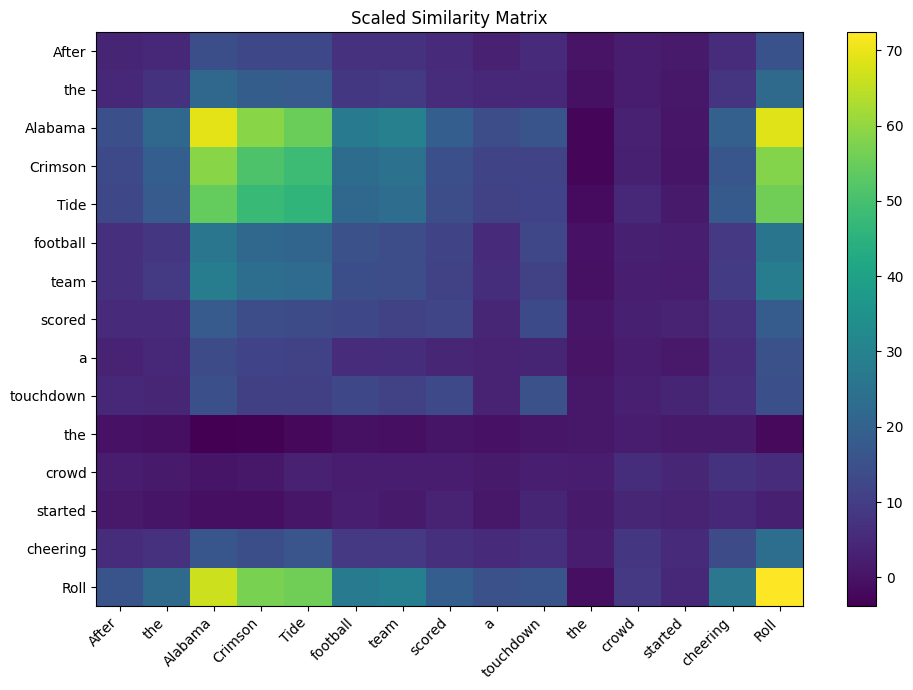

In [30]:
plt.figure(figsize=(10, 7))
plt.imshow(S, aspect='auto')
plt.colorbar()
plt.xticks(range(n), tokens, rotation=45, ha='right')
plt.yticks(range(n), tokens)
plt.title("Scaled Similarity Matrix")
plt.tight_layout()
plt.show()

## **Masking**

Before applying softmax, we apply a **mask** to prevent words from attending to future words.

In a left-to-right language modeling task, the model generates text one word at a time, so each word can only use information from itself and earlier words. Future words do not exist yet during generation.

However, during training, the model is given the entire sentence at once and processes all words in parallel. Without masking, a word could “look ahead” at future words, using information that would not be available in practice.

For example, in the sentence: *“After the Alabama Crimson Tide football team scored a touchdown, the crowd started cheering, ‘Roll ______”* the word *“Crimson”* should be able to use *“Alabama”* (which comes before it), but should not use *“football”* (which comes after it). Without masking, the attention mechanism would still allow *“Crimson”* to compare with *“football,”* meaning that future words would influence earlier ones.

If we did not add a mask, a model could learn patterns from future information instead of past context. An analogy for this concept would be a student checking the answer key while solving a math problem, which leads to relying on the final result instead of learning the steps needed to get there.

Masking prevents this by forcing the model to use only valid context.

In the similarity matrix, rows represent the word doing the looking, and columns represent the words being looked at. For a word in row `i`, any column `j > i` corresponds to a future word, so these positions must be removed.

A natural idea might be to set these entries to zero, but this would break normalization. Instead, we set them to negative infinity:

$$
S_{ij} = -\infty \text{ for } j > i
$$

After softmax, these values become zero. Now each word only attends to past and current positions.

In [31]:
# Apply causal masking using nested loops
for i in range(n):          # current word (query)
    for j in range(n):      # word being attended to (key)
        if j > i:
            S[i, j] = -np.inf   # mask future words

df_S = pd.DataFrame(S, index=tokens, columns=tokens)
print(df_S.round(2))

           After    the  Alabama  Crimson   Tide  football   team  scored  \
After       4.11   -inf     -inf     -inf   -inf      -inf   -inf    -inf   
the         5.09   7.31     -inf     -inf   -inf      -inf   -inf    -inf   
Alabama    14.90  22.01    69.22     -inf   -inf      -inf   -inf    -inf   
Crimson    12.94  19.01    58.74    50.97   -inf      -inf   -inf    -inf   
Tide       12.71  18.12    54.27    47.55  45.92      -inf   -inf    -inf   
football    6.63   8.23    26.23    21.73  21.03     15.22   -inf    -inf   
team        6.84   9.04    28.37    23.74  22.84     14.49  14.14    -inf   
scored      5.40   5.54    18.16    14.10  13.79     12.56  11.24   12.06   
a           3.34   4.69    13.52    11.39  11.24      5.90   6.19    4.39   
touchdown   4.82   4.27    14.75    10.67  10.57     12.81  10.84   13.01   
the        -0.09  -0.72    -3.84    -3.25  -2.27     -0.27  -0.69    0.33   
crowd       2.01   1.56     0.45     0.97   3.19      2.39   1.96    2.32   

##**Visualize Masked Similarity Matrix**

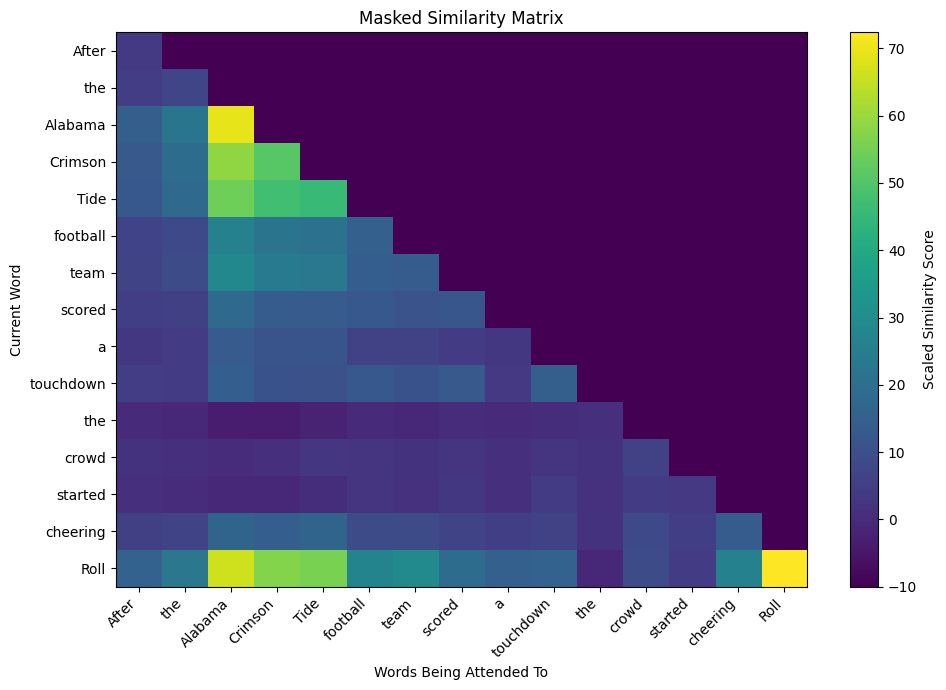

In [35]:
plt.figure(figsize=(10, 7))

# Replace -inf just for visualization
S_viz = np.where(np.isinf(S), -10, S)

plt.imshow(S_viz, aspect='auto')

plt.colorbar(label="Scaled Similarity Score")
plt.xticks(range(n), tokens, rotation=45, ha='right')
plt.yticks(range(n), tokens)

plt.title("Masked Similarity Matrix")
plt.xlabel("Words Being Attended To")
plt.ylabel("Current Word")

plt.tight_layout()
plt.show()

## **Softmax Normalization**

Currently, the similarity matrix contains raw scores. These scores show how strongly words are related, but they are not yet directly usable.

To combine information from other words, the model needs a clear way to decide how much each word should contribute. The softmax function converts each row of scores into a set of weights that:

- are all positive  
- sum to 1  
- emphasize the most relevant words  

This allows each word to form a weighted combination of other words, where more relevant words have a larger influence and less relevant words have little to no effect.

The **softmax function** we apply to each row of the similarity matrix is:

$$
Softmax(S) = \frac{e^{S_{ij}}}{\sum_{j=1}^{n} e^{S_{ij}}}
$$

As a result, the model can interpret each row as describing how much one word attends to all other words in the sequence.

For example, if the word “Roll” has high similarity with “Alabama,” “Crimson,” and “Tide,” then after applying softmax, those words will receive larger attention weights.

In this way, softmax converts the raw similarity scores into normalized attention weights that can be used to combine information from the value vectors.

In [36]:
def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

##**Temperature Scaling**

We apply an additional scaling factor, called **temperature**, before softmax:

$$
Softmax(S/T) = \frac{e^{S_{ij} / T}}{\sum_{j=1}^{n} e^{S_{ij} / T}}
$$

This helps control how concentrated the attention becomes. If the values are too large, softmax can place almost all the weight on a single word. By using a higher temperature, the weights are spread out more evenly to make the patterns easier to interpret. (For this demonstration we chose for our temperature T = 10)

In [37]:
T = 10
A = softmax(S / T)


print("Attention weights shape:", A.shape)
# Display attention weights with word labels for easier interpretation
df_A = pd.DataFrame(A, index=tokens, columns=tokens)
print(df_A.round(3))

Attention weights shape: (15, 15)
           After    the  Alabama  Crimson   Tide  football   team  scored  \
After      1.000  0.000    0.000    0.000  0.000     0.000  0.000   0.000   
the        0.445  0.555    0.000    0.000  0.000     0.000  0.000   0.000   
Alabama    0.004  0.009    0.987    0.000  0.000     0.000  0.000   0.000   
Crimson    0.007  0.013    0.672    0.309  0.000     0.000  0.000   0.000   
Tide       0.008  0.014    0.503    0.257  0.218     0.000  0.000   0.000   
football   0.049  0.058    0.348    0.222  0.207     0.116  0.000   0.000   
team       0.039  0.049    0.338    0.213  0.195     0.084  0.082   0.000   
scored     0.062  0.063    0.223    0.148  0.144     0.127  0.112   0.121   
a          0.071  0.081    0.196    0.159  0.157     0.092  0.094   0.079   
touchdown  0.055  0.052    0.148    0.098  0.098     0.122  0.100   0.124   
the        0.097  0.091    0.066    0.071  0.078     0.095  0.091   0.101   
crowd      0.080  0.077    0.069    0.072 

## **Final Attention Output**

In [39]:
output = A @ V

print("Output shape:", output.shape)
print(output)

Output shape: (15, 6)
[[0.8        1.3        0.4        1.4        1.         0.3       ]
 [1.26605022 1.52596845 0.20925445 1.39739885 0.45356103 0.46660979]
 [5.82287737 5.33183323 1.29798736 1.77644126 0.33222621 0.30263432]
 [5.32574639 5.24997572 0.93747185 1.82884844 0.24498978 0.30378985]
 [4.92038803 5.14909598 0.75735207 2.11304068 0.20160024 0.30406116]
 [4.12001518 4.49042057 1.01357141 2.02573607 0.30302764 0.3172751 ]
 [4.07028601 4.41786354 1.09288501 1.99657276 0.31449414 0.3146834 ]
 [3.27481542 3.58105613 1.61140652 1.81118611 0.68381978 0.31891933]
 [3.182702   3.47341363 1.2816663  1.81596787 0.53355373 0.345636  ]
 [2.64308939 2.78988742 2.22393644 1.61896615 1.11466938 0.33034368]
 [1.92029595 2.06075484 1.76029813 1.50700276 0.90947618 0.38874419]
 [1.80211972 1.97912749 1.56782622 1.79881904 0.77837169 0.37070606]
 [1.5632559  1.68027049 1.66903616 1.77320637 0.91137503 0.3637406 ]
 [2.44516518 2.59143665 1.29099637 2.21268297 0.5995191  0.33896708]
 [5.35255167

## **Visualize Attention Weights**

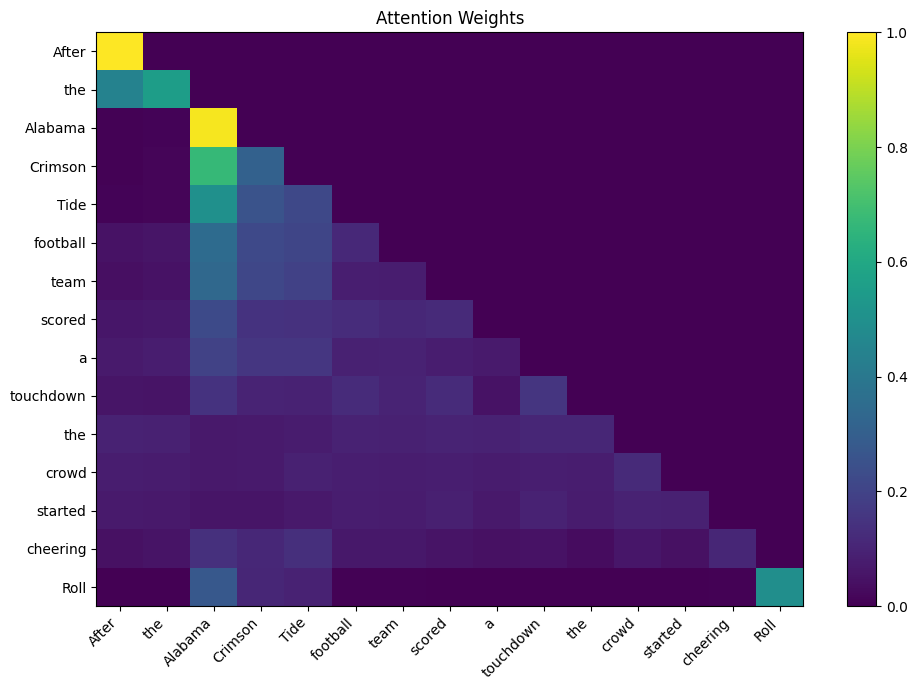

In [40]:
plt.figure(figsize=(10, 7))
plt.imshow(A, aspect='auto')
plt.colorbar()
plt.xticks(range(n), tokens, rotation=45, ha='right')
plt.yticks(range(n), tokens)
plt.title("Attention Weights")
plt.tight_layout()
plt.show()

## **Attention Distribution for 'Roll'**




Attention Distribution for 'Roll':
After     : 0.0017
the       : 0.0034
Alabama   : 0.2765
Crimson   : 0.1065
Tide      : 0.0938
football  : 0.0054
team      : 0.0065
scored    : 0.0024
a         : 0.0016
touchdown : 0.0017
the       : 0.0003
crowd     : 0.0009
started   : 0.0006
cheering  : 0.0049
Roll      : 0.4938


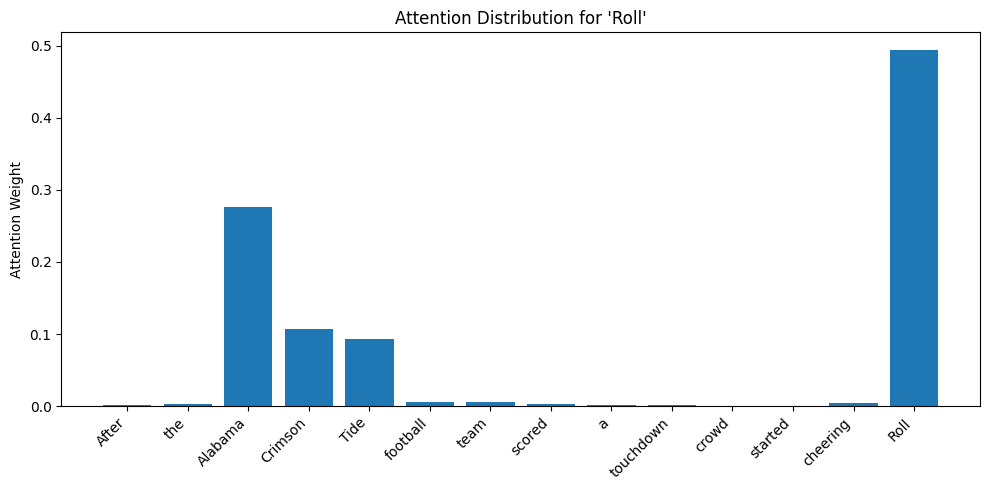

In [42]:
roll_idx = tokens.index("Roll")

print("Attention Distribution for 'Roll':")
for token, weight in zip(tokens, A[roll_idx, :]):
    print(f"{token:10s}: {weight:.4f}")

plt.figure(figsize=(10, 5))
plt.bar(tokens, A[roll_idx, :])
plt.xticks(rotation=45, ha='right')
plt.title("Attention Distribution for 'Roll'")
plt.ylabel("Attention Weight")
plt.tight_layout()
plt.show()


## **Conclusion**

In this notebook, the attention mechanism compares each word to every other word in the sentence to determine which words are most relevant. The similarity matrix captures these relationships, and the attention weights show how strongly each word focuses on others.

Looking at the attention weights, we notice that the word “Roll” puts more weight on words such as “Alabama,” “Crimson,” and “Tide.” These words share similar contextual meaning related to Alabama football, so they receive more attention than unrelated words.

The final step of attention is to combine the value vectors using these weights. This creates a new representation for “Roll” that is influenced by the words it attends to most. As a result, the representation of “Roll” contains information strongly associated with “Tide.”

Although this example does not directly predict the next word, the attention pattern shows which words are most relevant. For “Roll,” the highest attention is placed on words like “Tide,” “Alabama,” and “Crimson,” which are strongly related in context.

In a real model, this pattern would be used to help choose the next word. In practice, based on patterns learned from large amounts of text, a real large language model model would most likely select the word “Tide.”

Also, in this example, the vectors and matrices were manually designed to make these relationships easier to see. In practice, these values are learned from data, and the model discovers these patterns automatically.